In [1]:
## standard imports
import numpy as np
import scipy
import matplotlib.pyplot as plt

# binomial distribution

In [2]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html
from scipy.stats import binom

In [11]:
p = 0.3
n = 10
dist = binom(n,p)

In [12]:
samples = dist.rvs(size=3)
samples

array([4, 3, 6])

In [13]:
## I want to inspect the expected value and variance of the distribution
samples = dist.rvs(size=10_000)

mu = samples.mean()
print('mean: %.2f'%mu)

std = samples.std()
print('std: %.2f'%std)

mean: 3.02
std: 1.46


In [14]:
## compare with the limit n>>1
print(n*p)
print(np.sqrt(n*p*(1-p)))

3.0
1.4491376746189437


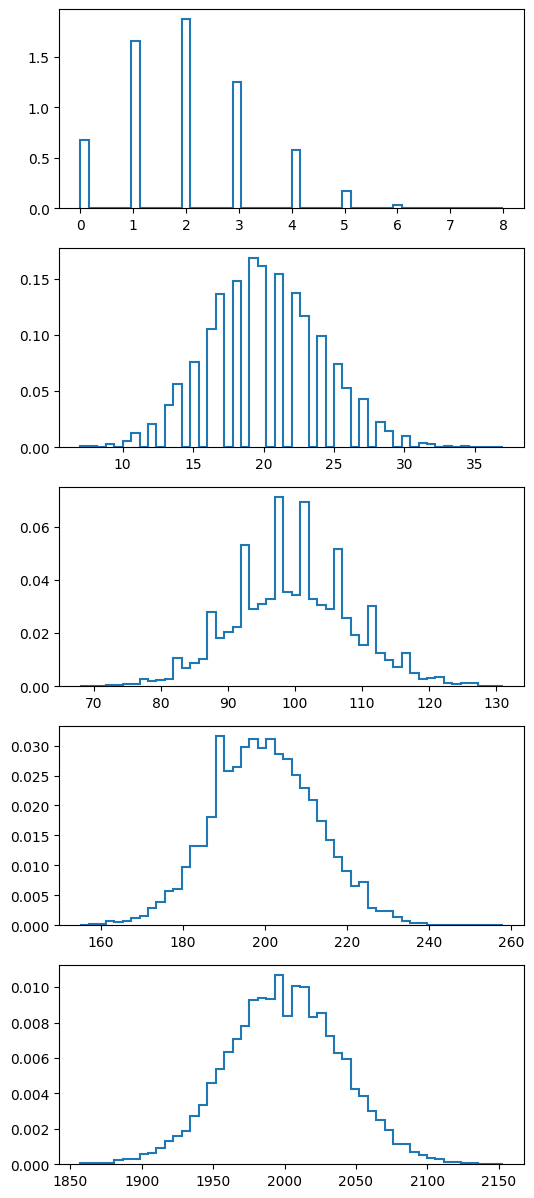

In [15]:
## plot the distribution for different values of n

p = 0.2

n_list = [10,100,500,1000,10_000]

fig, axs = plt.subplots(len(n_list),1,figsize=(6,3*len(n_list)))

for i in range(len(n_list)):
  n = n_list[i]
  dist = binom(n,p)
  samples = dist.rvs(size=10_000)
  axs[i].hist(samples,bins=50,histtype='step',density=True,linewidth=1.5,color='C0')

plt.show()

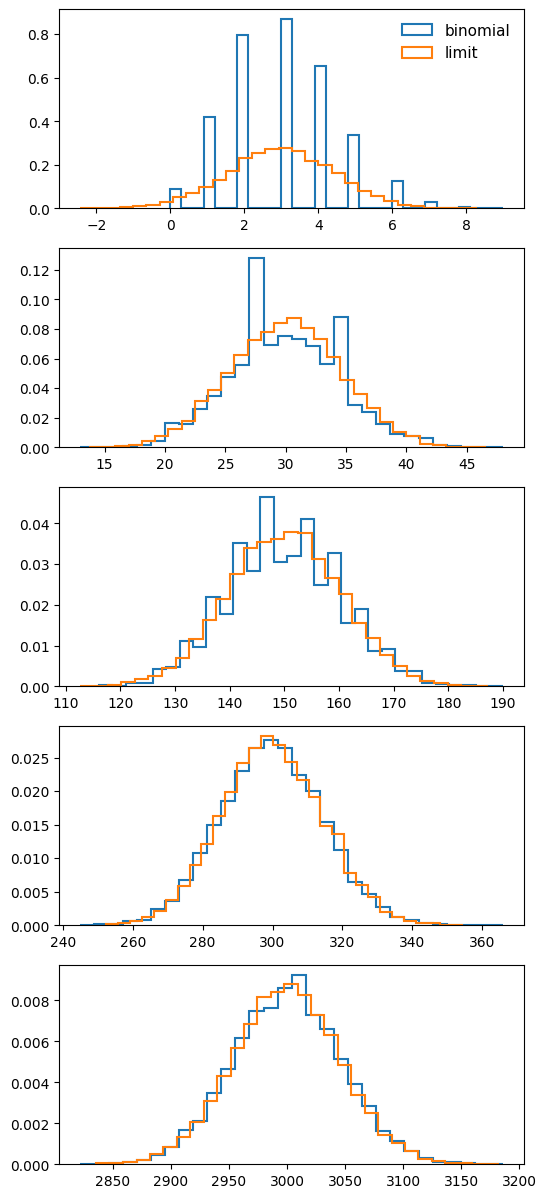

In [16]:
## plot the distribution for different values of n
## together with the n>>1 limit

p = 0.3

n_list = [10,100,500,1000,10_000]

fig, axs = plt.subplots(len(n_list),1,figsize=(6,3*len(n_list)))

for i in range(len(n_list)):
  n = n_list[i]
  dist = binom(n,p)
  samples = dist.rvs(size=10_000)
  axs[i].hist(samples,bins=30,histtype='step',density=True,linewidth=1.5,color='C0',label='binomial')

  samples = np.random.normal(loc=n*p, scale=(n*p*(1-p))**0.5, size=10_000)
  axs[i].hist(samples,bins=30,histtype='step',density=True,linewidth=1.5,color='C1',label='limit')

axs[0].legend(fontsize=11,frameon=False)

plt.show()

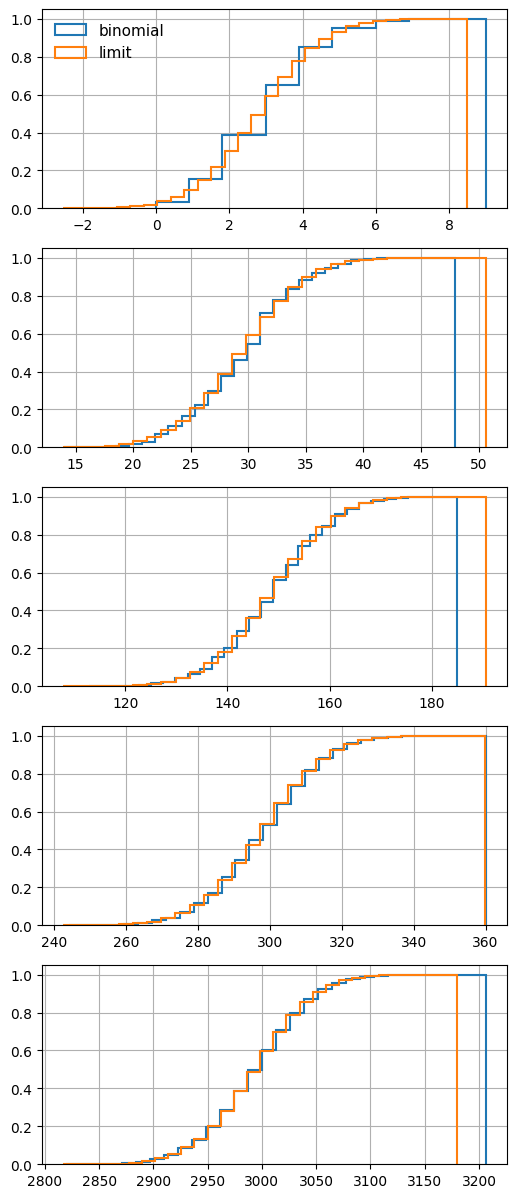

In [21]:
## show the approaching of the limit
## in terms of cumulative distributions

p = 0.3

n_list = [10,100,500,1000,10_000]

fig, axs = plt.subplots(len(n_list),1,figsize=(6,3*len(n_list)))

for i in range(len(n_list)):
  n = n_list[i]
  dist = binom(n,p)
  samples = dist.rvs(size=10_000)
  axs[i].hist(samples,bins=30,histtype='step',density=True,linewidth=1.5,color='C0',label='binomial',cumulative=True)

  samples = np.random.normal(loc=n*p, scale=(n*p*(1-p))**0.5, size=10_000)
  axs[i].hist(samples,bins=30,histtype='step',density=True,linewidth=1.5,color='C1',label='limit',cumulative=True)

  axs[i].grid()

axs[0].legend(fontsize=11,frameon=False)

plt.show()

In [ ]:
p = 0.3
n = 10_000
dist = binom(n,p)
binom_samples = dist.rvs(size=10_000)
gauss_samples = np.random.normal(n*p, np.sqrt(n*p*(1-p)),10_000)

binom_quantiles = np.quantile(binom_samples, q=[0.05,0.5,0.95])
gauss_quantiles = np.quantile(gauss_samples, q=[0.05,0.5,0.95])

print(binom_quantiles)
print(gauss_quantiles)

[2922. 2999. 3076.]
[2923.82456772 3000.8785147  3076.54694481]


# cdf and change of variables

In [30]:
## consider a uniform distribution
xmin = 1
xmax = 3

x_samples = np.random.uniform(xmin,xmax,size=10_000)

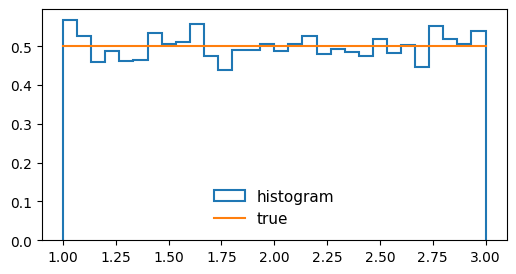

In [31]:
plt.figure(figsize=(6,3))

plt.hist(x_samples,bins=30,histtype='step',density=True,linewidth=1.5,color='C0',label='histogram')

X = np.linspace(xmin, xmax, 1000)
pX = np.ones_like(X)*(1/(xmax-xmin))

plt.plot(X,pX,color='C1',linewidth=1.5,label='true')

plt.legend(fontsize=11, frameon=False)

plt.show()

In [32]:
## consider y = x**2
y_samples = x_samples**2

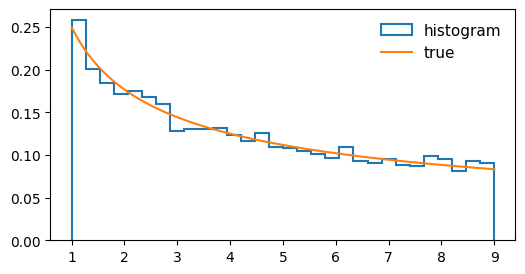

In [34]:
plt.figure(figsize=(6,3))

plt.hist(y_samples,bins=30,histtype='step',density=True,linewidth=1.5,color='C0',label='histogram')

Y = np.linspace(xmin**2, xmax**2, 1000)
pY = 1/(xmax-xmin)/np.abs(2*Y**0.5)

plt.plot(Y,pY,color='C1',linewidth=1.5,label='true')

plt.legend(fontsize=11, frameon=False)

plt.show()

In [35]:
mu_x = np.mean(x_samples)
mu_y = np.mean(y_samples)

print(r'$\mu_x = %.2f$'%mu_x)
print(r'$\mu_y = %.2f$'%mu_y**0.5)

$\mu_x = 2.00$
$\mu_y = 2.08$


In [36]:
std_x = np.std(x_samples)
std_y = np.std(y_samples)

print(r'$\std_x = %.2f$'%std_x)
print(r'$\std_y = %.2f$'%std_y**0.5)

$\std_x = 0.58$
$\std_y = 1.53$


In [37]:
median_x = np.median(x_samples)
median_y = np.median(y_samples)

print(r'$\median_x = %.2f$'%median_x)
print(r'$\median_y = %.2f$'%median_y**0.5)

$\median_x = 2.00$
$\median_y = 2.00$


In [39]:
q_x = np.quantile(x_samples, q=[0.05,0.5,0.95])
q_y = np.quantile(y_samples, q=[0.05,0.5,0.95])

print(q_x)
print(q_y**0.5)

[1.09303528 2.004254   2.90655547]
[1.09303529 2.004254   2.90655547]


In [41]:
## there is nothing special in starting from a uniform distributions

x_samples = np.random.normal(3.1, 0.1, 10_000)
y_samples = x_samples**2

In [42]:
q_x = np.quantile(x_samples, q=[0.05,0.5,0.95])
q_y = np.quantile(y_samples, q=[0.05,0.5,0.95])

print(q_x)
print(q_y**0.5)

[2.93484907 3.09913758 3.26516154]
[2.93484907 3.09913758 3.26516154]


In [43]:
## but be careful when the transformation is not bi-jective!

x_samples = np.random.normal(0.1, 3.1, 10_000)
y_samples = x_samples**2

In [44]:
q_x = np.quantile(x_samples, q=[0.05,0.5,0.95])
q_y = np.quantile(y_samples, q=[0.05,0.5,0.95])

print(q_x)
print(q_y**0.5)

[-5.01730673  0.03333996  5.21355714]
[0.18655079 2.11659871 6.05233034]


# Monty Hall problem

In [76]:
num_experiments = 1_000_00

doors = np.array([np.random.choice([1,0,0],replace=False,size=3) for i in range(num_experiments)]).T

In [77]:
## conventionally, suppose that you are assigned the first door
initial_door = doors[0]

other_door = 1 - initial_door

In [78]:
## the probability of winning if I take my door is
np.mean(initial_door)

np.float64(0.33273)

In [79]:
## the probability of winning if I change door is
np.mean(other_door)

np.float64(0.66727)

In [80]:
## let's plot the probability of winning as a function of num_experiments
x = np.arange(1,num_experiments+1,1)
y0 = np.cumsum(initial_door)/x
y1 = np.cumsum(other_door)/x

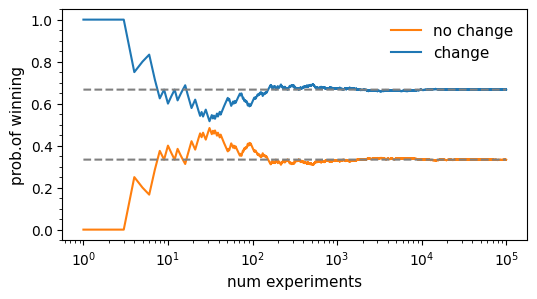

In [81]:
plt.figure(figsize=(6,3))

plt.plot(x,y0,color='C1',label='no change')
plt.plot(x,y1,color='C0',label='change')

plt.plot(x,np.ones_like(x)/3,color='gray',linestyle='--')
plt.plot(x,np.ones_like(x)*2/3,color='gray',linestyle='--')

plt.minorticks_on()

plt.xscale('log')

plt.xlabel('num experiments', fontsize=11)
plt.ylabel('prob.of winning', fontsize=11)

plt.legend(fontsize=11,frameon=False)
plt.show()